In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

In [4]:
print(df.dtypes)

Дата            object
Склад            int64
Контрагент      object
Номенклатура    object
Количество       int64
dtype: object


Сразу переведем столбец "Дата" в правильный формат

In [5]:
df['Дата'] = pd.to_datetime(df['Дата'])

In [6]:
print(df.dtypes)

Дата            datetime64[ns]
Склад                    int64
Контрагент              object
Номенклатура            object
Количество               int64
dtype: object


Сгруппируйте данные по дате, посчитайте количество продаж

In [7]:
grouped_df = df.groupby('Дата')['Количество'].sum().reset_index()

Вывести несколько первых строк сгруппированных данных

In [8]:
print(grouped_df.head())

        Дата  Количество
0 2018-01-04        3734
1 2018-01-05        3643
2 2018-01-06        3193
3 2018-01-07        3298
4 2018-01-09        4055


Нарисуйте график продаж у `grouped_df`

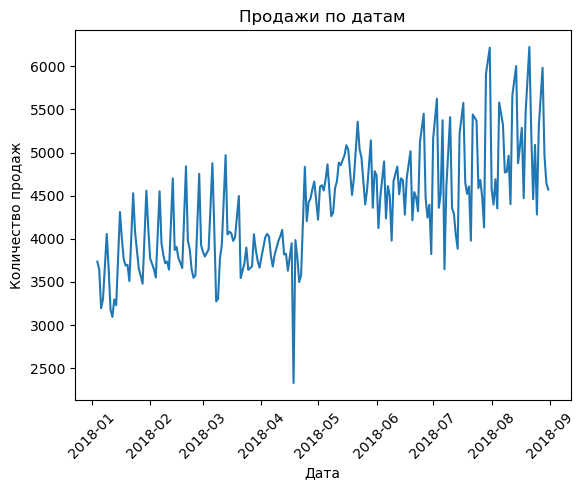

In [9]:
plt.figure()
plt.plot(grouped_df['Дата'], grouped_df['Количество'])
plt.title('Продажи по датам')
plt.xlabel('Дата')
plt.ylabel('Количество продаж')
plt.xticks(rotation=45)
plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

In [ ]:
На графике отображена динамика продаж по датам. Видно, что продажи имеют колебательный характер с периодическими пиками и спадами.
Наблюдаются отдельные резкие всплески — возможные акции или сезонные эффекты.
В целом можно предположить наличие тренда и сезонности (например, рост в определённые дни недели).
Также присутствуют выбросы, которые требуют дополнительного анализа.

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [10]:
outlier = df.loc[df['Количество'].idxmax()]
print(outlier)

Дата            2018-06-28 00:00:00
Склад                             1
Контрагент              address_208
Номенклатура              product_0
Количество                      200
Name: 218822, dtype: object


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [13]:
df['weekday'] = df['Дата'].dt.day_name()

filtered = df[
    (df['Дата'].dt.month.isin([6,7,8])) &
    (df['Склад'] == 3) &
    (df['weekday'] == 'Wednesday')
]

top_product = (
    filtered.groupby('Номенклатура')['Количество']
    .sum()
    .sort_values(ascending=False)
    .head(1)
)

print(top_product)

Номенклатура
product_1    2267
Name: Количество, dtype: int64


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [35]:
weather = pd.read_csv('weather.csv')

In [40]:
weather = weather.groupby('Дата')['T'].mean().reset_index()

In [37]:
print(weather.dtypes)

Дата    datetime64[ns]
T               object
dtype: object


In [38]:
weather['T'] = weather['T'].str.replace(',', '.')
weather['T'] = pd.to_numeric(weather['T'], errors='coerce')

In [39]:
print(weather.dtypes)

Дата    datetime64[ns]
T              float64
dtype: object


In [41]:
merged = pd.merge(grouped_df, weather, on='Дата', how='inner')

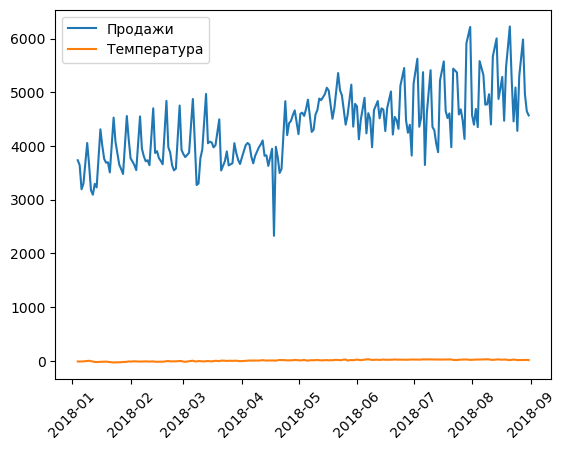

In [42]:
plt.figure()
plt.plot(merged['Дата'], merged['Количество'], label='Продажи')
plt.plot(merged['Дата'], merged['T'], label='Температура')
plt.legend()
plt.xticks(rotation=45)
plt.show()

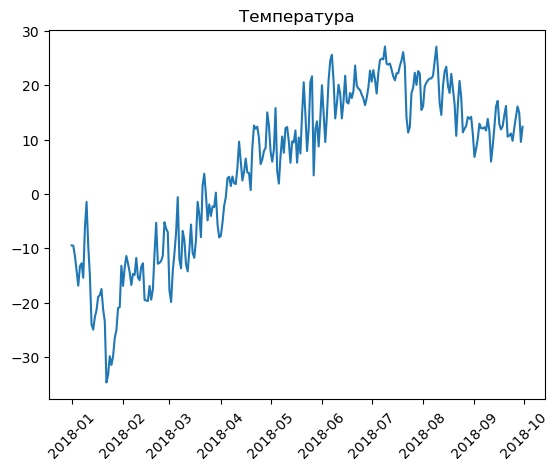

In [43]:
plt.figure()
plt.plot(weather['Дата'], weather['T'])
plt.title('Температура')
plt.xticks(rotation=45)
plt.show()